# Elementy odstające (*outliers*)

> **Kontekst ćwiczeń:** Pracujemy z danymi sprzedażowymi sklepu internetowego.  
> Cel: zidentyfikować nietypowe obserwacje, zrozumieć ich przyczyny  
> i podjąć decyzję — usunąć, skorygować czy zachować.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_rows', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

np.random.seed(42)

## Czym są elementy odstające?

**Element odstający (outlier)** to obserwacja, która znacząco odbiega od pozostałych danych. Może wynikać z:

- **błędu pomiaru / wpisu** — literówka, awaria czujnika, podwójne zaksięgowanie
- **rzeczywistego zdarzenia** — wyprzedaż Black Friday, awaria serwera, viralowy post
- **zmiany procesu** — nowa kampania reklamowa, zmiana cen, wejście na nowy rynek

### Dlaczego to ważne?

Outliersy mogą poważnie wpływać na analizę statystyczną i modele predykcyjne:
średnia arytmetyczna, odchylenie standardowe, regresja liniowa — wszystko to jest
wrażliwe na wartości ekstremalne. Jednocześnie outliersy mogą nieść
**cenną informację biznesową**, więc nie zawsze należy je usuwać.

## Typy elementów odstających

| Typ | Opis | Przykład |
|-----|------|---------|
| **Jednowymiarowy** | Ekstremalna wartość jednej zmiennej | Sprzedaż 5× wyższa niż zwykle |
| **Wielowymiarowy** | Nietypowa kombinacja zmiennych (każda z osobna OK) | Klient 22-letni z dochodem 500 tys. zł |
| **Kontekstowy** | Wartość normalna w jednym kontekście, odstająca w innym | 200 sztuk w poniedziałek vs 200 sztuk w niedzielę |

## Metody wykrywania elementów odstających

| # | Metoda | Typ | Założenia |
|---|--------|-----|-----------|
| 1 | Wykres pudełkowy (Boxplot) | wizualna | brak |
| 2 | Metoda IQR | statystyczna, nieparametryczna | brak |
| 3 | Z-score | statystyczna, parametryczna | rozkład normalny |
| 4 | Zmodyfikowany Z-score (MAD) | statystyczna, odporna (robust) | brak |
| 5 | Percentyle | statystyczna, nieparametryczna | brak |

## Przykład

In [ ]:
# Wynagrodzenia brutto (tys. zł) — 24 pracowników małej firmy IT
df = pd.DataFrame({
    'pracownik': [
        'Anna', 'Bartek', 'Celina', 'Dawid', 'Ewa',       # juniorzy
        'Filip', 'Gosia', 'Hubert', 'Iwona', 'Jakub',      # regularni
        'Kasia', 'Lena', 'Marcin', 'Natalia', 'Oskar',     # regularni
        'Patryk', 'Robert', 'Sylwia', 'Tomek', 'Urszula',  # seniorzy
        'Wiktor',                                            # kierownik działu
        'Zuzia',                                             # stażystka (pół etatu?)
        'Dyrektor',                                          # CEO
        'Gosia_2',                                           # ← błąd wpisu: 5.5 → 55.0
    ],
    'wynagrodzenie': [
        4.2, 4.5, 4.8, 5.0, 5.1,
        5.3, 5.5, 5.5, 5.8, 6.0,
        6.2, 6.3, 6.5, 6.8, 7.0,
        7.2, 7.5, 8.0, 8.5, 9.0,
        12.0,
        1.8,
        25.0,
        55.0,
    ]
})

wyn = df['wynagrodzenie']

print("DANE: wynagrodzenia pracowników (tys. zł)")
print("=" * 50)
print(df.to_string(index=False))
print(f"\nLiczba obserwacji: {len(df)}")

wyn = df['wynagrodzenie']
print(f"\nŚrednia:  {wyn.mean():.2f} tys. zł")
print(f"Mediana:  {wyn.median():.2f} tys. zł")
print(f"Std:      {wyn.std():.2f} tys. zł")
print(f"Min:      {wyn.min():.2f} tys. zł")
print(f"Max:      {wyn.max():.2f} tys. zł")

print(f"\n→ Średnia ({wyn.mean():.1f}) jest wyraźnie wyższa od mediany ({wyn.median():.1f})")
print("  — to już sygnał, że w danych mogą być outliersy górne!")

DANE: wynagrodzenia pracowników (tys. zł)
pracownik  wynagrodzenie
     Anna           4.20
   Bartek           4.50
   Celina           4.80
    Dawid           5.00
      Ewa           5.10
    Filip           5.30
    Gosia           5.50
   Hubert           5.50
    Iwona           5.80
    Jakub           6.00
    Kasia           6.20
     Lena           6.30
   Marcin           6.50
  Natalia           6.80
    Oskar           7.00
   Patryk           7.20
   Robert           7.50
   Sylwia           8.00
    Tomek           8.50
  Urszula           9.00
   Wiktor          12.00
    Zuzia           1.80
 Dyrektor          25.00
  Gosia_2          55.00

Liczba obserwacji: 24

Średnia:  9.10 tys. zł
Mediana:  6.25 tys. zł
Std:      10.67 tys. zł
Min:      1.80 tys. zł
Max:      55.00 tys. zł

→ Średnia (9.1) jest wyraźnie wyższa od mediany (6.2)
  — to już sygnał, że w danych mogą być outliersy górne!


# Boxplot metoda

### Metoda 1: Wykres pudełkowy (Boxplot)

Boxplot wizualizuje rozkład danych przez kwartyle. Elementy poza „wąsami"
(1.5 × IQR od krawędzi pudełka) traktowane są jako potencjalne outliersy.

Jest to jednocześnie **wizualizacja** i **metoda detekcji** — idealna na początek.

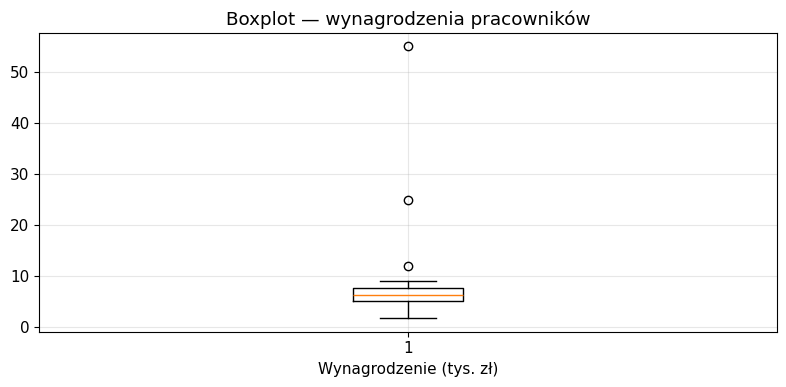

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
bp_vertical = ax.boxplot(df['wynagrodzenie'])
ax.set_xlabel('Wynagrodzenie (tys. zł)')
ax.set_title('Boxplot — wynagrodzenia pracowników')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

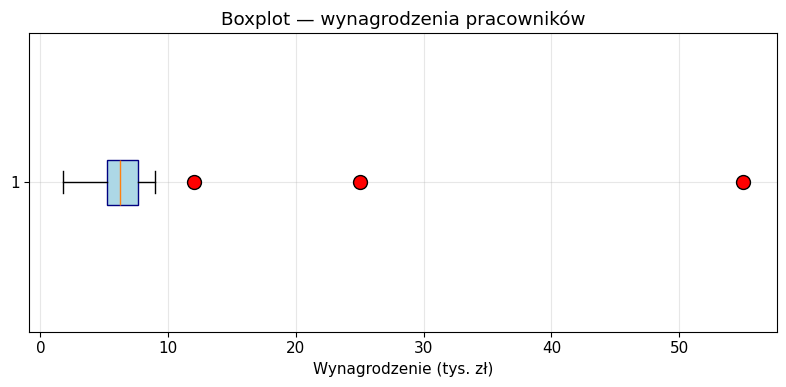

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
bp_horizontal = ax.boxplot(df['wynagrodzenie'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue', edgecolor='navy'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=10))
ax.set_xlabel('Wynagrodzenie (tys. zł)')
ax.set_title('Boxplot — wynagrodzenia pracowników')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Metoda 2: Rozstęp ćwiartkowy (IQR)

**Wzór:**
$$\text{IQR} = Q_3 - Q_1$$

**Granice:**
- dolna: $Q_1 - 1.5 \times \text{IQR}$
- górna: $Q_3 + 1.5 \times \text{IQR}$

Wartości poza granicami uznajemy za outliersy. Metoda **nieparametryczna** —
nie wymaga rozkładu normalnego. To ta sama logika, którą stosuje boxplot.

In [ ]:
wyn = df['wynagrodzenie']
Q1 = wyn.quantile(0.25)
Q3 = wyn.quantile(0.75)
IQR = Q3 - Q1
dolny_limit = Q1 - 1.5 * IQR
gorny_limit = Q3 + 1.5 * IQR

print("METODA IQR")
print("=" * 50)
print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"\nDolny limit = {Q1:.2f} − 1.5 × {IQR:.2f} = {dolny_limit:.2f}")
print(f"Górny limit = {Q3:.2f} + 1.5 × {IQR:.2f} = {gorny_limit:.2f}")

maska_iqr = (wyn < dolny_limit) | (wyn > gorny_limit)
print(f"\nWykryte outliersy ({maska_iqr.sum()}):")
print(df[maska_iqr][['pracownik', 'wynagrodzenie']].to_string(index=False))

METODA IQR
Q1 = 5.25
Q3 = 7.62
IQR = 2.38

Dolny limit = 5.25 − 1.5 × 2.38 = 1.69
Górny limit = 7.62 + 1.5 × 2.38 = 11.19

Wykryte outliersy (3):
pracownik  wynagrodzenie
   Wiktor          12.00
 Dyrektor          25.00
  Gosia_2          55.00


### Metoda 3: Z-score (standaryzacja)

**Wzór:**
$$z_i = \frac{x_i - \bar{x}}{s}$$

Wartość $|z| > 3$ oznacza, że obserwacja leży ponad 3 odchylenia standardowe
od średniej — w rozkładzie normalnym dotyczy to < 0.3% danych.

**Uwaga:** Średnia i odchylenie standardowe **same są wrażliwe na outliersy**,
więc skrajne wartości „rozciągają" skalę i mogą maskować umiarkowane anomalie.

In [ ]:
z_scores = np.abs(stats.zscore(wyn))
df['z_score'] = z_scores

print("METODA Z-SCORE")
print("=" * 50)
print(f"Średnia (x̄) = {wyn.mean():.2f}")
print(f"Odch. std (s) = {wyn.std():.2f}")

maska_z3 = z_scores > 3
maska_z2 = z_scores > 2

print(f"\nOutliersy (|z| > 3): {maska_z3.sum()}")
if maska_z3.sum() > 0:
    print(df[maska_z3][['pracownik', 'wynagrodzenie', 'z_score']].to_string(index=False))

print(f"\nPotencjalne outliersy (|z| > 2): {maska_z2.sum()}")
if maska_z2.sum() > 0:
    print(df[maska_z2][['pracownik', 'wynagrodzenie', 'z_score']].to_string(index=False))

print("\n→ Wartość 55.0 (Gosia_2) tak mocno zawyża std,")
print("  że np. Zuzia (1.8) czy Dyrektor (25.0) mogą nie wyjść jako outliersy!")

METODA Z-SCORE
Średnia (x̄) = 9.10
Odch. std (s) = 10.67

Outliersy (|z| > 3): 1
pracownik  wynagrodzenie  z_score
  Gosia_2          55.00     4.39

Potencjalne outliersy (|z| > 2): 1
pracownik  wynagrodzenie  z_score
  Gosia_2          55.00     4.39

→ Wartość 55.0 (Gosia_2) tak mocno zawyża std,
  że np. Zuzia (1.8) czy Dyrektor (25.0) mogą nie wyjść jako outliersy!


### Metoda 4: Zmodyfikowany Z-score (MAD)

Klasyczny Z-score używa średniej i std, które same są wrażliwe na outliersy.
**Zmodyfikowany Z-score** zastępuje je odporniejszymi odpowiednikami:

$$\text{MAD} = \text{median}(|x_i - \widetilde{x}|)$$

$$M_i = \frac{0.6745 \cdot (x_i - \widetilde{x})}{\text{MAD}}$$

Próg: $|M_i| > 3.5$ (zalecenie Iglewicza i Hoaglina, 1993).

Kluczowa różnica: **mediana i MAD nie zmieniają się** pod wpływem jednej
ekstremalnej wartości — dlatego metoda jest **odporna (robust)**.

In [ ]:
mediana = wyn.median()
mad = np.median(np.abs(wyn - mediana))
modified_z = np.abs(0.6745 * (wyn - mediana) / mad)
df['mod_z_score'] = modified_z

print("METODA MAD (Zmodyfikowany Z-score)")
print("=" * 50)
print(f"Mediana = {mediana:.2f}")
print(f"MAD     = {mad:.2f}")

maska_mad = modified_z > 3.5
print(f"\nOutliersy (|M| > 3.5): {maska_mad.sum()}")
if maska_mad.sum() > 0:
    print(df[maska_mad][['pracownik', 'wynagrodzenie', 'mod_z_score']].to_string(index=False))

print("\n→ MAD wykrywa więcej anomalii niż Z-score,")
print("  bo Gosia_2 (55.0) nie zaburza miar bazowych.")

METODA MAD (Zmodyfikowany Z-score)
Mediana = 6.25
MAD     = 1.20

Outliersy (|M| > 3.5): 2
pracownik  wynagrodzenie  mod_z_score
 Dyrektor          25.00        10.54
  Gosia_2          55.00        27.40

→ MAD wykrywa więcej anomalii niż Z-score,
  bo Gosia_2 (55.0) nie zaburza miar bazowych.


### Metoda 5: Percentyle

Najprostsza metoda: odcinamy skrajne wartości na wybranym progu procentowym.

- **Rygorystycznie:** poniżej 1. i powyżej 99. percentyla
- **Łagodnie:** poniżej 5. i powyżej 95. percentyla

Metoda przydatna szczególnie przy **winzorowaniu** — zastępowaniu ekstremalnych
wartości wartościami granicznymi.

In [ ]:
print("METODA PERCENTYLI")
print("=" * 50)

for dolny_p, gorny_p in [(1, 99), (5, 95)]:
    p_low = wyn.quantile(dolny_p / 100)
    p_high = wyn.quantile(gorny_p / 100)
    maska = (wyn < p_low) | (wyn > p_high)

    print(f"\nPróg {dolny_p}–{gorny_p} percentyl:")
    print(f"  Dolna granica = {p_low:.2f}")
    print(f"  Górna granica = {p_high:.2f}")
    print(f"  Wykryte outliersy: {maska.sum()}")
    if maska.sum() > 0:
        print(df[maska][['pracownik', 'wynagrodzenie']].to_string(index=False))

METODA PERCENTYLI

Próg 1–99 percentyl:
  Dolna granica = 2.35
  Górna granica = 48.10
  Wykryte outliersy: 2
pracownik  wynagrodzenie
    Zuzia           1.80
  Gosia_2          55.00

Próg 5–95 percentyl:
  Dolna granica = 4.25
  Górna granica = 23.05
  Wykryte outliersy: 4
pracownik  wynagrodzenie
     Anna           4.20
    Zuzia           1.80
 Dyrektor          25.00
  Gosia_2          55.00


## Outliersy wielowymiarowe

W praktyce anomalie często ujawniają się dopiero gdy spojrzymy na **kombinację zmiennych**.
Każda zmienna z osobna może wyglądać normalnie, ale ich **połączenie** jest nietypowe.

DANE: doświadczenie vs wynagrodzenie
pracownik  doswiadczenie  wynagrodzenie
     Anna              1           4.50
   Bartek              2           5.00
   Celina              3           5.50
    Dawid              5           6.50
      Ewa              7           7.00
    Filip              8           7.50
    Gosia             10           8.00
   Hubert             12           9.00
    Iwona             15          10.00
    Jakub              3          12.00
    Kasia              6           4.00
     Lena             20           8.00

→ Jakub: 3 lata doświadczenia, a zarabia 12.0 — protegowany?
→ Kasia: 6 lat doświadczenia, a zarabia 4.0 — niedoceniana?
→ Lena: 20 lat i tylko 8.0 — stagnacja?

  Żadna z tych wartości nie jest ekstremalna SAMA W SOBIE,
  ale ich KOMBINACJA jest podejrzana!


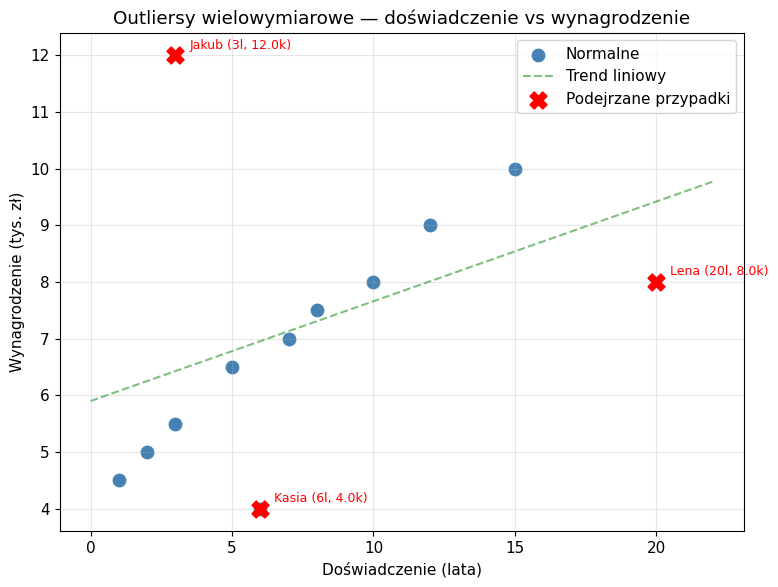

In [ ]:
# Dane: doświadczenie (lata) vs wynagrodzenie
df_2d = pd.DataFrame({
    'pracownik': ['Anna', 'Bartek', 'Celina', 'Dawid', 'Ewa',
                   'Filip', 'Gosia', 'Hubert', 'Iwona', 'Jakub',
                   'Kasia', 'Lena'],
    'doswiadczenie': [1, 2, 3, 5, 7, 8, 10, 12, 15, 3, 6, 20],
    'wynagrodzenie': [4.5, 5.0, 5.5, 6.5, 7.0, 7.5, 8.0, 9.0, 10.0, 12.0, 4.0, 8.0]
})

print("DANE: doświadczenie vs wynagrodzenie")
print("=" * 45)
print(df_2d.to_string(index=False))

# Z-score per kolumna
z_dosw = np.abs(stats.zscore(df_2d['doswiadczenie']))
z_wyn = np.abs(stats.zscore(df_2d['wynagrodzenie']))
df_2d['outlier'] = (z_dosw > 2) | (z_wyn > 2)

print(f"\n→ Jakub: 3 lata doświadczenia, a zarabia 12.0 — protegowany?")
print(f"→ Kasia: 6 lat doświadczenia, a zarabia 4.0 — niedoceniana?")
print(f"→ Lena: 20 lat i tylko 8.0 — stagnacja?")
print(f"\n  Żadna z tych wartości nie jest ekstremalna SAMA W SOBIE,")
print(f"  ale ich KOMBINACJA jest podejrzana!")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))

normalne = df_2d[~df_2d['outlier']]
outl = df_2d[df_2d['outlier']]

ax.scatter(normalne['doswiadczenie'], normalne['wynagrodzenie'],
           s=80, color='steelblue', label='Normalne')

# Zaznacz interesujące przypadki ręcznie
for _, row in df_2d.iterrows():
    if row['pracownik'] in ['Jakub', 'Kasia', 'Lena']:
        ax.scatter(row['doswiadczenie'], row['wynagrodzenie'],
                   s=150, color='red', marker='X', zorder=5)
        ax.annotate(f"{row['pracownik']} ({row['doswiadczenie']}l, {row['wynagrodzenie']}k)",
                    (row['doswiadczenie'], row['wynagrodzenie']),
                    textcoords="offset points", xytext=(10, 5), fontsize=9, color='red')

# Linia trendu
z = np.polyfit(df_2d['doswiadczenie'], df_2d['wynagrodzenie'], 1)
x_line = np.linspace(0, 22, 100)
ax.plot(x_line, np.polyval(z, x_line), 'g--', alpha=0.5, label='Trend liniowy')

ax.scatter([], [], s=150, color='red', marker='X', label='Podejrzane przypadki')
ax.set_xlabel('Doświadczenie (lata)')
ax.set_ylabel('Wynagrodzenie (tys. zł)')
ax.set_title('Outliersy wielowymiarowe — doświadczenie vs wynagrodzenie')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Zadanie

Plik `sprzedaz_dzienna.csv` zawiera **90 dni** danych sprzedażowych sklepu internetowego
z kolumnami: `sprzedaz`, `dzien_tygodnia`, `przychod`, `wizyty`, `zwroty`.

**Polecenia:**

1. Wczytaj dane i wyświetl podstawowe statystyki opisowe (wszystkie kolumny numeryczne).
2. Narysuj serię czasową sprzedaży oraz boxplot — ogólny i wg dnia tygodnia.
3. Zastosuj **trzy metody** wykrywania outlierów dla kolumny `sprzedaz`: IQR, Z-score, MAD. Porównaj wyniki.
4. Zbadaj **outliersy wielowymiarowe**: zrób scatter plot `wizyty` vs `sprzedaz` — czy widzisz nietypowe kombinacje?
5. Sprawdź kolumnę `zwroty` — czy widzisz dni z podejrzanie wysokim procentem zwrotów względem sprzedaży?
6. Dla każdego wykrytego outliera zaproponuj hipotezę: co mogło się stać?
7. Zaproponuj strategię postępowania z każdym outlierem (usunąć / skorygować / zachować / oznaczyć).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('sprzedaz_dzienna.csv', index_col=0)
df['data'] = pd.to_datetime(df['data'])

print("Podstawowe statystyki opisowe:")
print(df[['sprzedaz', 'przychod', 'wizyty', 'zwroty']].describe().round(2))

Podstawowe statystyki opisowe:
       sprzedaz  przychod   wizyty  zwroty
count     90.00     90.00    90.00   90.00
mean     163.03   9109.68  5214.49    8.60
std       53.75   4389.05  1723.74    4.18
min        8.00    442.06   410.00    1.00
25%      144.75   7575.17  4432.25    6.00
50%      163.00   8964.28  5066.00    8.00
75%      176.75  10060.07  5887.00   11.00
max      437.00  39900.00 14344.00   24.00


/tmp/ipykernel_259/2334692142.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(data_by_day, labels=order, patch_artist=True,


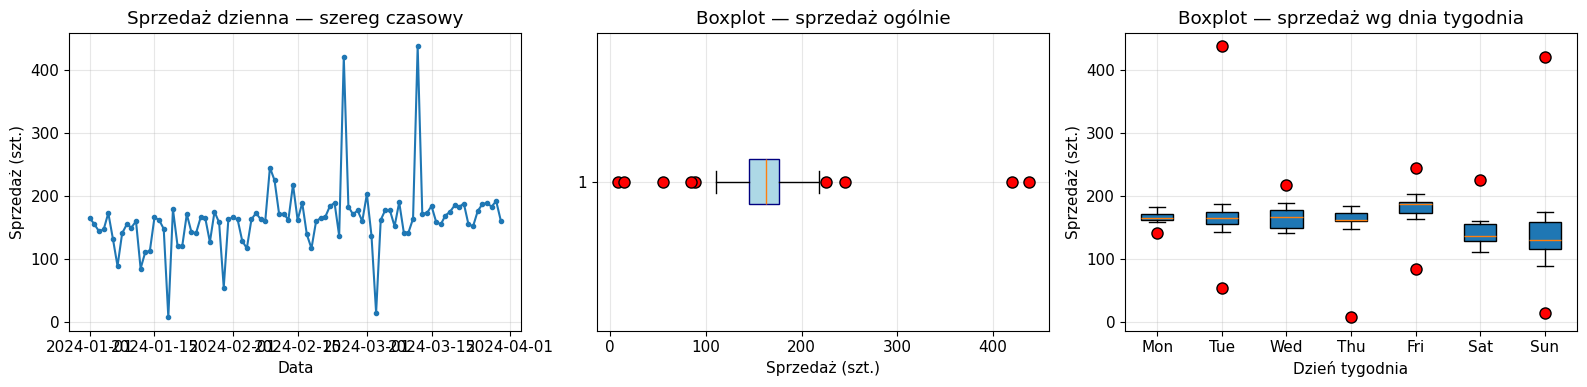

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(df['data'], df['sprzedaz'], marker='o', markersize=3)
axes[0].set_title('Sprzedaż dzienna — szereg czasowy')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Sprzedaż (szt.)')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['sprzedaz'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue', edgecolor='navy'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
axes[1].set_title('Boxplot — sprzedaż ogólnie')
axes[1].set_xlabel('Sprzedaż (szt.)')
axes[1].grid(True, alpha=0.3)

order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
data_by_day = [df[df['dzien_tygodnia'] == d]['sprzedaz'].values for d in order]
axes[2].boxplot(data_by_day, labels=order, patch_artist=True,
                flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
axes[2].set_title('Boxplot — sprzedaż wg dnia tygodnia')
axes[2].set_xlabel('Dzień tygodnia')
axes[2].set_ylabel('Sprzedaż (szt.)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
sp = df['sprzedaz']

Q1 = sp.quantile(0.25)
Q3 = sp.quantile(0.75)
IQR = Q3 - Q1
lo_iqr = Q1 - 1.5 * IQR
hi_iqr = Q3 + 1.5 * IQR
mask_iqr = (sp < lo_iqr) | (sp > hi_iqr)

print("METODA IQR")
print("=" * 50)
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Dolny limit: {lo_iqr:.2f}, Górny limit: {hi_iqr:.2f}")
print(f"\nOutliersy ({mask_iqr.sum()}):")
print(df[mask_iqr][['data', 'sprzedaz', 'dzien_tygodnia']].to_string(index=False))

z_scores = np.abs(stats.zscore(sp))
df['z_score'] = z_scores
mask_z3 = z_scores > 3
mask_z2 = z_scores > 2

print("\nMETODA Z-SCORE")
print("=" * 50)
print(f"Średnia={sp.mean():.2f}, Std={sp.std():.2f}")
print(f"\nOutliersy |z|>3 ({mask_z3.sum()}):")
print(df[mask_z3][['data', 'sprzedaz', 'dzien_tygodnia', 'z_score']].to_string(index=False))
print(f"\nOutliersy |z|>2 ({mask_z2.sum()}):")
print(df[mask_z2][['data', 'sprzedaz', 'dzien_tygodnia', 'z_score']].to_string(index=False))

mediana = sp.median()
mad = np.median(np.abs(sp - mediana))
mod_z = np.abs(0.6745 * (sp - mediana) / mad)
df['mod_z'] = mod_z
mask_mad = mod_z > 3.5

print("\nMETODA MAD (zmodyfikowany Z-score)")
print("=" * 50)
print(f"Mediana={mediana:.2f}, MAD={mad:.2f}")
print(f"\nOutliersy |M|>3.5 ({mask_mad.sum()}):")
print(df[mask_mad][['data', 'sprzedaz', 'dzien_tygodnia', 'mod_z']].to_string(index=False))

METODA IQR
Q1=144.75, Q3=176.75, IQR=32.00
Dolny limit: 96.75, Górny limit: 224.75

Outliersy (9):
      data  sprzedaz dzien_tygodnia
2024-01-07        89            Sun
2024-01-12        85            Fri
2024-01-18         8            Thu
2024-01-30        55            Tue
2024-02-09       245            Fri
2024-02-10       225            Sat
2024-02-25       420            Sun
2024-03-03        15            Sun
2024-03-12       437            Tue

METODA Z-SCORE
Średnia=163.03, Std=53.75

Outliersy |z|>3 (2):
      data  sprzedaz dzien_tygodnia  z_score
2024-02-25       420            Sun     4.81
2024-03-12       437            Tue     5.13

Outliersy |z|>2 (5):
      data  sprzedaz dzien_tygodnia  z_score
2024-01-18         8            Thu     2.90
2024-01-30        55            Tue     2.02
2024-02-25       420            Sun     4.81
2024-03-03        15            Sun     2.77
2024-03-12       437            Tue     5.13

METODA MAD (zmodyfikowany Z-score)
Mediana=163.00

Korelacja wizyty–sprzedaż: 0.799


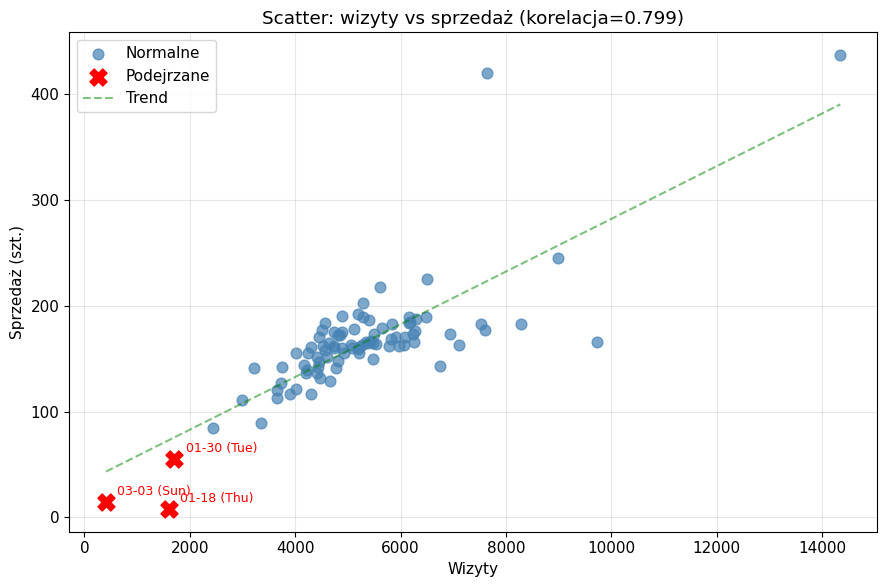

In [ ]:
corr = df[['wizyty', 'sprzedaz']].corr().iloc[0, 1]
print(f"Korelacja wizyty–sprzedaż: {corr:.3f}")

fig, ax = plt.subplots(figsize=(9, 6))

normal = df[(df['sprzedaz'] >= 50) & (df['wizyty'] >= 2000)]
suspicious = df[(df['sprzedaz'] < 50) | (df['wizyty'] < 2000)]

ax.scatter(normal['wizyty'], normal['sprzedaz'],
           s=60, color='steelblue', alpha=0.7, label='Normalne')
ax.scatter(suspicious['wizyty'], suspicious['sprzedaz'],
           s=150, color='red', marker='X', zorder=5, label='Podejrzane')

for _, row in suspicious.iterrows():
    ax.annotate(f"{row['data'].strftime('%m-%d')} ({row['dzien_tygodnia']})",
                (row['wizyty'], row['sprzedaz']),
                textcoords='offset points', xytext=(8, 5),
                fontsize=9, color='red')

z_fit = np.polyfit(df['wizyty'], df['sprzedaz'], 1)
x_line = np.linspace(df['wizyty'].min(), df['wizyty'].max(), 100)
ax.plot(x_line, np.polyval(z_fit, x_line), 'g--', alpha=0.5, label='Trend')

ax.set_xlabel('Wizyty')
ax.set_ylabel('Sprzedaż (szt.)')
ax.set_title(f'Scatter: wizyty vs sprzedaż (korelacja={corr:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df['pct_zwrotow'] = (df['zwroty'] / df['sprzedaz'] * 100).round(2)

print("Statystyki % zwrotów:")
print(df['pct_zwrotow'].describe().round(2))

Q1z = df['pct_zwrotow'].quantile(0.25)
Q3z = df['pct_zwrotow'].quantile(0.75)
IQRz = Q3z - Q1z
hi_zwroty = Q3z + 1.5 * IQRz

mask_zw = df['pct_zwrotow'] > hi_zwroty
print(f"\nGórny limit IQR dla % zwrotów: {hi_zwroty:.2f}%")
print(f"\nDni z podejrzanie wysokim % zwrotów ({mask_zw.sum()}):")
print(df[mask_zw][['data', 'dzien_tygodnia', 'sprzedaz', 'zwroty', 'pct_zwrotow']].to_string(index=False))

Statystyki % zwrotów:
count   90.00
mean     5.42
std      2.16
min      2.04
25%      4.05
50%      5.34
75%      6.34
max     13.95
Name: pct_zwrotow, dtype: float64

Górny limit IQR dla % zwrotów: 9.78%

Dni z podejrzanie wysokim % zwrotów (4):
      data dzien_tygodnia  sprzedaz  zwroty  pct_zwrotow
2024-01-18            Thu         8       1        12.50
2024-02-12            Mon       172      24        13.95
2024-02-13            Tue       162      19        11.73
2024-02-14            Wed       218      22        10.09


In [ ]:
hipotezy = {
    '2024-01-18 (Thu, 8 szt.)':   'Awaria systemu/sklepu przez większość dnia — zarówno wizyty (1600), sprzedaż (8) i przychód (442 zł) są dramatycznie niskie.',
    '2024-01-30 (Tue, 55 szt.)':  'Możliwa przerwa techniczna w połowie dnia lub problem z płatnościami — wizyty 1709 (bardzo mało jak na wtorek).',
    '2024-03-03 (Sun, 15 szt.)':  'Podobna sytuacja — 410 wizyt to prawie zero. Prawdopodobna awaria lub chwilowe wyłączenie serwisu.',
    '2024-01-07 (Sun, 89 szt.)':  'Niedzielna sprzedaż — wzorzec sezonowy (niższy ruch), ale czy to outlier, czy norma dla niedziel?',
    '2024-02-09 (Fri, 245 szt.)': 'Wzrost sprzedaży w piątek, możliwa akcja promocyjna lub wyprzedaż.',
    '2024-02-25 (Sun, 420 szt.)': 'Wyjątkowy niedzielny szczyt: 420 szt. przy przychodzie 39 900 zł — prawdopodobnie duże zamówienie B2B lub viralowa akcja.',
    '2024-03-12 (Tue, 437 szt.)': 'Rekordowa sprzedaż: 437 szt., 14 344 wizyty, 25 743 zł — szczyt kampanii marketingowej lub flash sale.',
    '2024-02-12-14 (zwroty)':     '3 kolejne dni z >10% zwrotów — prawdopodobnie wadliwa partia towaru lub błąd w opisie produktu.',
}

for k, v in hipotezy.items():
    print(f"\n{k}:\n  → {v}")


2024-01-18 (Thu, 8 szt.):
  → Awaria systemu/sklepu przez większość dnia — zarówno wizyty (1600), sprzedaż (8) i przychód (442 zł) są dramatycznie niskie.

2024-01-30 (Tue, 55 szt.):
  → Możliwa przerwa techniczna w połowie dnia lub problem z płatnościami — wizyty 1709 (bardzo mało jak na wtorek).

2024-03-03 (Sun, 15 szt.):
  → Podobna sytuacja — 410 wizyt to prawie zero. Prawdopodobna awaria lub chwilowe wyłączenie serwisu.

2024-01-07 (Sun, 89 szt.):
  → Niedzielna sprzedaż — wzorzec sezonowy (niższy ruch), ale czy to outlier, czy norma dla niedziel?

2024-02-09 (Fri, 245 szt.):
  → Wzrost sprzedaży w piątek, możliwa akcja promocyjna lub wyprzedaż.

2024-02-25 (Sun, 420 szt.):
  → Wyjątkowy niedzielny szczyt: 420 szt. przy przychodzie 39 900 zł — prawdopodobnie duże zamówienie B2B lub viralowa akcja.

2024-03-12 (Tue, 437 szt.):
  → Rekordowa sprzedaż: 437 szt., 14 344 wizyty, 25 743 zł — szczyt kampanii marketingowej lub flash sale.

2024-02-12-14 (zwroty):
  → 3 kolejne dni z >10

In [33]:
strategia = {
    '2024-01-18 (awaria, 8 szt.)':    'USUNĄĆ lub OZNACZYĆ — błąd techniczny, wartość niereprezentatywna. Przy modelowaniu wykluczyć.',
    '2024-01-30 (55 szt.)':            'OZNACZYĆ — możliwa awaria połówkowa. Zweryfikować z logami techniczymi, następnie decydować.',
    '2024-03-03 (awaria, 15 szt.)':    'USUNĄĆ lub OZNACZYĆ — identycznie jak 01-18.',
    '2024-01-07 i podobne niedziele':  'ZACHOWAĆ — to kontekstowy outlier. Niedziele strukturalnie różnią się od reszty tygodnia.',
    '2024-02-09 i 02-10 (promocja)':   'ZACHOWAĆ z etykietą "promocja" — prawdziwe zdarzenie biznesowe, cenne dla analizy efektywności kampanii.',
    '2024-02-25 (420 szt.)':           'ZACHOWAĆ z etykietą "zdarzenie specjalne" — zweryfikować z zespołem marketingu.',
    '2024-03-12 (437 szt.)':           'ZACHOWAĆ z etykietą "kampania" — rekordowy dzień, wartość autentyczna.',
    '2024-02-12-14 (zwroty)':          'ZACHOWAĆ, ale OZNACZYĆ i ZBADAĆ — uruchomić procedurę reklamacyjną. Nie usuwać z danych, bo wzorzec zwrotów jest istotnym sygnałem jakości.',
}

print("Strategia postępowania z outlierami:\n")
for k, v in strategia.items():
    print(f"  {k}:\n    → {v}\n")

Strategia postępowania z outlierami:

  2024-01-18 (awaria, 8 szt.):
    → USUNĄĆ lub OZNACZYĆ — błąd techniczny, wartość niereprezentatywna. Przy modelowaniu wykluczyć.

  2024-01-30 (55 szt.):
    → OZNACZYĆ — możliwa awaria połówkowa. Zweryfikować z logami techniczymi, następnie decydować.

  2024-03-03 (awaria, 15 szt.):
    → USUNĄĆ lub OZNACZYĆ — identycznie jak 01-18.

  2024-01-07 i podobne niedziele:
    → ZACHOWAĆ — to kontekstowy outlier. Niedziele strukturalnie różnią się od reszty tygodnia.

  2024-02-09 i 02-10 (promocja):
    → ZACHOWAĆ z etykietą "promocja" — prawdziwe zdarzenie biznesowe, cenne dla analizy efektywności kampanii.

  2024-02-25 (420 szt.):
    → ZACHOWAĆ z etykietą "zdarzenie specjalne" — zweryfikować z zespołem marketingu.

  2024-03-12 (437 szt.):
    → ZACHOWAĆ z etykietą "kampania" — rekordowy dzień, wartość autentyczna.

  2024-02-12-14 (zwroty):
    → ZACHOWAĆ, ale OZNACZYĆ i ZBADAĆ — uruchomić procedurę reklamacyjną. Nie usuwać z danych, bo wzorze